# American Sign Language Letters — Baseline

Versi **baseline** tanpa transfer learning. Model dibangun dari scratch menggunakan CNN sederhana.

**Alur kerja:**
1. Load & split dataset
2. Bangun CNN sederhana dari scratch
3. Training
4. Visualisasi hasil
5. Simpan model

## 1. Import & Konfigurasi

In [ ]:
import os
import pathlib

import matplotlib.pyplot as plt
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [ ]:
# ── Path & file ───────────────────────────────────────────────────────────────
# Mengarah langsung ke folder dataset di Google Drive kamu
DATASET_DIR = pathlib.Path("/content/drive/MyDrive/asl/American_Sign_Language_Letters_Multiclass")

CHECKPOINT_PATH: str = "./checkpoint_baseline/"
TFLITE_FNAME: str = "model_baseline.tflite"

# ── Dataset ───────────────────────────────────────────────────────────────────
BATCH_SIZE: int = 64
IMAGE_SIZE: tuple = (64, 64)       # Lebih kecil dari versi utama (160x160)
IMAGE_SHAPE: tuple = IMAGE_SIZE + (3,)
VALIDATION_SPLIT: float = 0.2

# ── Training ──────────────────────────────────────────────────────────────────
LEARNING_RATE: float = 0.001
EPOCHS: int = 30

# ── Early stopping ────────────────────────────────────────────────────────────
EARLYSTOP_PATIENCE: int = 5

print("Konfigurasi baseline berhasil dimuat.")
print(f"Dataset target: {DATASET_DIR}")

Konfigurasi baseline berhasil dimuat.
Dataset target: /content/drive/MyDrive/asl/American_Sign_Language_Letters_Multiclass


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load & Split Dataset

In [ ]:
def split_dataset(validation_split: float):
    train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        directory=DATASET_DIR,
        validation_split=validation_split,
        subset="training",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
    )
    validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        directory=DATASET_DIR,
        validation_split=validation_split,
        subset="validation",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
    )
    class_names = train_dataset.class_names
    train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
    return train_dataset, validation_dataset, class_names


train_dataset, validation_dataset, class_names = split_dataset(VALIDATION_SPLIT)

print(f"Jumlah kelas : {len(class_names)}")
print(f"Nama kelas   : {class_names}")

Found 3408 files belonging to 28 classes.
Using 2727 files for training.
Found 3408 files belonging to 28 classes.
Using 681 files for validation.
Jumlah kelas : 28
Nama kelas   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 3. Bangun Model CNN Sederhana (From Scratch)

Arsitektur minimalis: 3 blok Conv → MaxPool, diikuti Dense layer.

In [ ]:
def build_model(num_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential(
        [
            # Normalisasi pixel [0,255] → [0,1]
            tf.keras.layers.Rescaling(1.0 / 255, input_shape=IMAGE_SHAPE),

            # Blok 1
            tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),

            # Blok 2
            tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),

            # Blok 3
            tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D(),

            # Classifier
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_classes, activation="softmax", name="outputs"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    return model


model = build_model(len(class_names))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,145,564 (4.37 MB)

 Trainable params: 1,145,564 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [ ]:
earlystop_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=EARLYSTOP_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[earlystop_callback],
)

Epoch 1/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 611s 14s/step - accuracy: 0.0418 - loss: 3.3296 - val_accuracy: 0.0426 - val_loss: 3.3041
Epoch 2/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0524 - loss: 3.2764 - val_accuracy: 0.0529 - val_loss: 3.2853
Epoch 3/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0847 - loss: 3.1856 - val_accuracy: 0.0734 - val_loss: 3.2123
Epoch 4/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1258 - loss: 3.0699 - val_accuracy: 0.0940 - val_loss: 3.1419
Epoch 5/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1870 - loss: 2.8825 - val_accuracy: 0.1424 - val_loss: 3.0252
Epoch 6/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2450 - loss: 2.6013 - val_accuracy: 0.1865 - val_loss: 2.8922
Epoch 7/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3586 - loss: 2.2504 - val_accuracy: 0.2261 - val_loss: 2.8122
Epoch 8/30
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4430 - loss: 1.9331 - val_accuracy: 0.2819 - 

## 5. Visualisasi Hasil Training

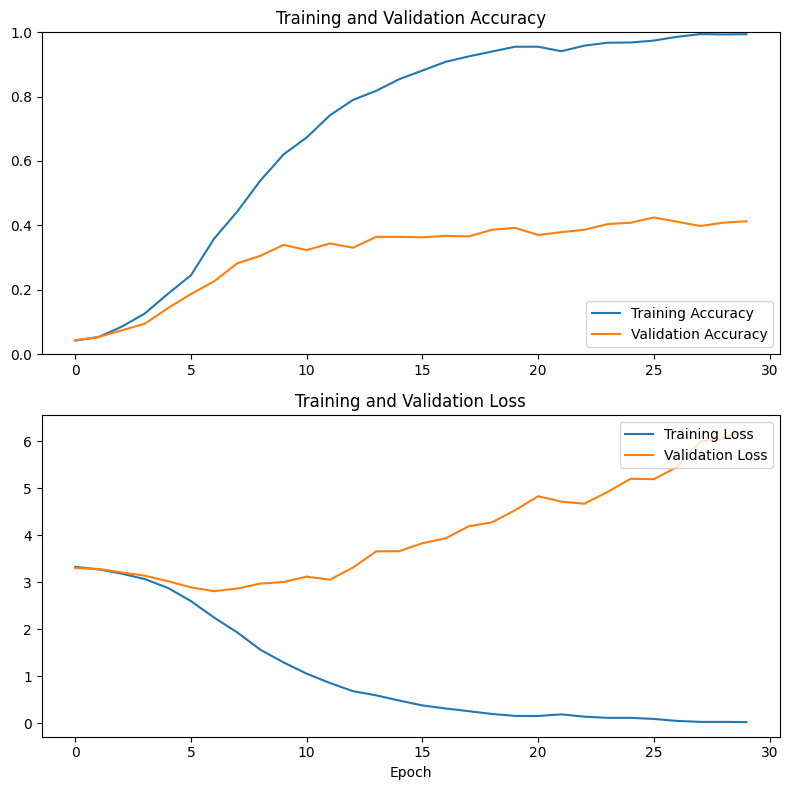

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(8, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.ylim([0.0, 1.0])
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

## 6. Simpan Model

In [ ]:
# SavedModel
tf.saved_model.save(model, CHECKPOINT_PATH)
print(f"SavedModel disimpan ke: {CHECKPOINT_PATH}")

# TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
lite_model_content = converter.convert()

tflite_path = os.path.join(CHECKPOINT_PATH, TFLITE_FNAME)
with open(tflite_path, "wb") as f:
    f.write(lite_model_content)
print(f"TFLite model disimpan ke: {tflite_path}")